# 32b. Content-Addressed Caching & Leased Workers

**Tier:** Production & Safety
**Estimated time:** 45 minutes
**Prerequisites:** 16 (RAG vs CAG), 19c (Async Agents), 32 (Cost Engineering)
**Priority:** 🟢 Nice-to-have — a cost/throughput optimization that pays off once an agent recomputes the same work repeatedly across sessions or repos; not needed for a first system. *If skipped, revisit when:* your agent re-does identical parsing/embedding/analysis, or a warm run should be nearly free but isn't.
**Source material:** The Sovereign Imperia Citadel (`services/compile/store.py` content-addressed `.legion` cache + Bloom filter, `services/army/pool.py` leased verify-before-count worker pool), https://github.com/Hvuj/The-Soverign-Imperia-citadel

## What You'll Learn
- **Content-addressed caching**: key work by a hash of its *content*, so identical inputs are never recomputed — even across paths, sessions, or repos
- **Bloom filters**: an O(1), memory-tiny "have we already done this?" probe with no false negatives
- **Leased, verify-before-count workers**: bound concurrency, expire stale work automatically, and only let *verified* results count
- Measuring cache hit-rate on a repeated workload — the mechanism behind "warm runs are almost free"

## Why This Matters
Notebook 32 cut cost by routing to cheaper models and caching prompt prefixes. There's a deeper win: most agent work is *deterministic given its input* — parsing a file, embedding a chunk, compiling a fact. If the input hasn't changed, the output can't have either, so recomputing it is pure waste. Content-addressed caching keys results by a hash of their input, giving near-100% hit-rates on warm runs (Citadel reports ~100% cache hits on warm builds). Pair it with a worker pool that expires stale work and verifies results before counting them, and you get cheap, safe throughput.

## The `__pycache__` insight

You've already used content-addressed caching without naming it. When Python imports a module it writes a compiled `.pyc` into `__pycache__`, tagged so that if the source is unchanged, it skips recompiling. Git does the same: every object is stored under the SHA-1 of its content, so identical files are stored once. **The key is a hash of the content, not a name or a location.**

Apply that to agent work. Parsing a file, embedding a chunk, running a static analysis — all *deterministic given their input*. So:

- Compute a **key = hash(input)** once.
- If the key is in the cache, return the stored result. **Zero recompute.**
- Two different file paths with identical content share one cache entry (**dedup**).

Before even touching the cache, a **Bloom filter** answers *"have we possibly seen this key?"* in O(1) and a few kilobytes. It can say "definitely no" (skip the lookup entirely) or "probably yes" (do the real lookup). It never says "no" when the answer is yes — **no false negatives** — which is exactly what a cache gate needs.

Finally, when work *does* need doing, Citadel's `army/pool.py` runs it on a **bounded pool** where each worker holds a **TTL lease** (so hung work expires instead of blocking forever) and results are **verified before they count** (a wrong-but-fast answer is worse than no answer). Small deterministic tasks solved locally cost **zero cloud tokens**.

Everything below is standard-library Python.

In [1]:
import hashlib, time, random
from dataclasses import dataclass, field
random.seed(7)
print("Content-addressed cache demo — stdlib only, fully offline.")

Content-addressed cache demo — stdlib only, fully offline.


## Part 1 — The content-addressed store

`compile_fact` stands in for any expensive, deterministic transform of an input (parse, embed, analyze). The cache keys results by `sha256(content ⊕ relpath-independent)` — we hash the *content*, so the same bytes under two different paths hit the same entry. We count real compiles vs. cache hits to prove the recompute is actually avoided.

In [2]:
def content_key(content: str) -> str:
    # The address IS the content hash. Same bytes -> same key, anywhere.
    return hashlib.sha256(content.encode("utf-8")).hexdigest()

class ContentAddressedStore:
    def __init__(self):
        self.facts = {}           # key -> compiled result
        self.compiles = 0         # how many times we actually did the expensive work
        self.hits = 0
    def _expensive_compile(self, content):
        # Simulate real work: a deterministic but non-trivial transform.
        self.compiles += 1
        h = hashlib.sha256(content.encode()).hexdigest()
        return {"tokens": len(content.split()), "digest": h[:12]}
    def get(self, content):
        key = content_key(content)
        if key in self.facts:
            self.hits += 1
            return self.facts[key], "HIT"
        result = self._expensive_compile(content)
        self.facts[key] = result
        return result, "MISS"

store = ContentAddressedStore()

fileA = "def add(a, b):\n    return a + b\n"
fileB = "def add(a, b):\n    return a + b\n"     # identical content, different 'path'
fileC = "def sub(a, b):\n    return a - b\n"

for name, content in [("A", fileA), ("B", fileB), ("A-again", fileA), ("C", fileC)]:
    result, status = store.get(content)
    print(f"  {name:8s} {status}  digest={result['digest']}")

print(f"\nUnique contents compiled: {store.compiles}   cache hits: {store.hits}")
print("A and B share one entry (identical content) ->", content_key(fileA) == content_key(fileB))

  A        MISS  digest=ba1a531f581d
  B        HIT  digest=ba1a531f581d
  A-again  HIT  digest=ba1a531f581d
  C        MISS  digest=ee7f606cede9

Unique contents compiled: 2   cache hits: 2
A and B share one entry (identical content) -> True


## Part 2 — The Bloom-filter gate (O(1), no false negatives)

A Bloom filter is a bit array plus `k` hash functions. To add a key, set the `k` bits it hashes to. To test a key, check those `k` bits: if *any* is 0 the key is **definitely absent** (skip the real lookup); if all are 1 it's **probably present** (do the lookup). It never misses a real member — only occasionally says "probably" for a non-member (a tunable false-positive rate). A few kilobytes gates a huge store.

In [3]:
class BloomFilter:
    def __init__(self, n_bits=4096, k=4):
        self.n_bits = n_bits
        self.k = k
        self.bits = bytearray(n_bits // 8)
    def _positions(self, key):
        # Derive k independent positions from one sha256 digest.
        h = hashlib.sha256(key.encode()).digest()
        for i in range(self.k):
            chunk = int.from_bytes(h[i*4:(i+1)*4], "big")
            yield chunk % self.n_bits
    def add(self, key):
        for p in self._positions(key):
            self.bits[p // 8] |= (1 << (p % 8))
    def __contains__(self, key):
        return all(self.bits[p // 8] & (1 << (p % 8)) for p in self._positions(key))

bloom = BloomFilter(n_bits=4096, k=4)
known = [content_key(c) for c in (fileA, fileC)]
for key in known:
    bloom.add(key)

# No false negatives: everything we added is definitely reported present.
print("known keys all present:", all(k in bloom for k in known))

# Measure the false-positive rate on 5000 keys we never added.
fp = sum(1 for _ in range(5000) if hashlib.sha256(str(random.random()).encode()).hexdigest() in bloom)
print(f"false positives on 5000 unseen keys: {fp}  (~{fp/5000:.2%})")

def gated_get(store, bloom, content):
    key = content_key(content)
    if key not in bloom:              # definitely-absent -> skip lookup, go compile
        bloom.add(key)
        return store.get(content)[0], "MISS (bloom skip)"
    return store.get(content)         # probably-present -> real lookup confirms

print(gated_get(store, bloom, fileA)[1])   # known -> HIT via real lookup

known keys all present: True
false positives on 5000 unseen keys: 0  (~0.00%)
HIT


## Part 3 — Leased, verify-before-count workers

When work *does* need doing, run it on a bounded pool with two safety rules from Citadel's `army/pool.py`:

- **TTL lease.** Each task runs under a lease with a deadline. If a worker overruns (hangs, loops), its lease expires and its result is **discarded and reaped** — no work outlives its grant, so one stuck task can't block the queue forever.
- **Verify before count.** A result only counts if a `verify` function passes. A fast-but-wrong answer is rejected, not cached. Small deterministic tasks solved locally cost **zero cloud tokens**.

In [4]:
@dataclass
class Task:
    tid: str
    payload: int
    duration: float      # simulated seconds the work takes
    correct: bool        # whether the (simulated) result will pass verify

def run_pool(tasks, *, lease_ttl, verify):
    now = 0.0
    results = {"verified": [], "rejected": [], "reaped": []}
    tokens_spent = 0
    for t in tasks:
        start = now
        deadline = start + lease_ttl
        finish = start + t.duration          # when the work would complete
        if finish > deadline:
            results["reaped"].append(t.tid)  # lease expired -> discard, don't count
            now = deadline                   # reaper collects at the deadline
            continue
        now = finish
        # Local deterministic task -> 0 cloud tokens.
        answer = t.payload * 2 if t.correct else t.payload * 2 + 1
        if verify(t, answer):
            results["verified"].append((t.tid, answer))
        else:
            results["rejected"].append(t.tid)   # wrong result never counts / never cached
    return results, tokens_spent

tasks = [
    Task("t1", 10, duration=0.4, correct=True),
    Task("t2", 21, duration=0.4, correct=False),   # will fail verify
    Task("t3", 33, duration=2.0, correct=True),     # will overrun the lease
    Task("t4",  7, duration=0.3, correct=True),
]
def verify(task, answer):
    return answer == task.payload * 2      # the known-correct check

res, tokens = run_pool(tasks, lease_ttl=1.0, verify=verify)
print("verified (counted):", res["verified"])
print("rejected (failed verify):", res["rejected"])
print("reaped (lease expired):", res["reaped"])
print("cloud tokens spent on these local tasks:", tokens)

verified (counted): [('t1', 20), ('t4', 14)]
rejected (failed verify): ['t2']
reaped (lease expired): ['t3']
cloud tokens spent on these local tasks: 0


## Warm-run economics: hit-rate over a repeated workload

Now the payoff. We replay a realistic workload where most inputs repeat (an agent re-touching the same files across a session). The cache hit-rate climbs toward 100% as the store warms — the reason a warm run is almost free.

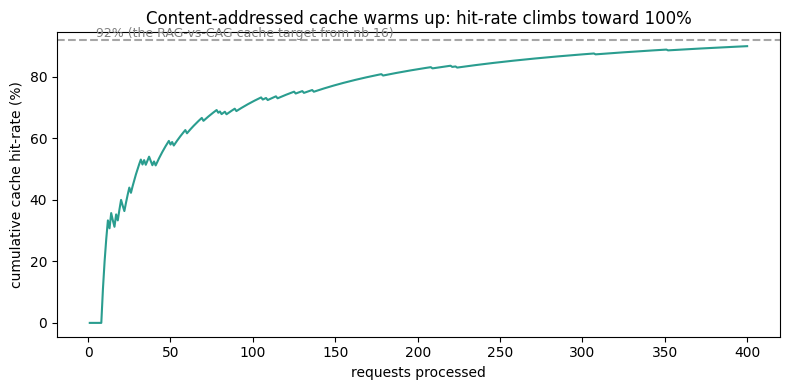

Final hit-rate: 90.0%  (compiled 40 unique blocks for 400 requests)


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

# A workload of 400 requests over 40 distinct contents, Zipf-ish repetition.
distinct = [f"content-block-{i}" for i in range(40)]
weights = [1.0 / (i + 1) for i in range(40)]     # a few blocks are very common
workload = random.choices(distinct, weights=weights, k=400)

warm = ContentAddressedStore()
hit_rate_curve = []
for n, content in enumerate(workload, 1):
    _, status = warm.get(content)
    hit_rate_curve.append(warm.hits / n)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(workload) + 1), [r * 100 for r in hit_rate_curve], color="#2a9d8f")
ax.axhline(92, ls="--", color="gray", alpha=0.7)
ax.text(5, 93, "92% (the RAG-vs-CAG cache target from nb 16)", color="gray", fontsize=9)
ax.set_xlabel("requests processed")
ax.set_ylabel("cumulative cache hit-rate (%)")
ax.set_title("Content-addressed cache warms up: hit-rate climbs toward 100%")
plt.tight_layout(); plt.show()

print(f"Final hit-rate: {warm.hits/len(workload):.1%}  "
      f"(compiled {warm.compiles} unique blocks for {len(workload)} requests)")

*Once the cache is warm, almost every request is served from the store — the same "hot data is nearly free" economics as notebook 16's CAG, but keyed by content hash so it works across paths, sessions, and repos.*

## Exercises

In [6]:
# Exercise 1 (Warm-up): shrink the Bloom filter
# Task: rebuild BloomFilter with n_bits=512 and re-measure the false-positive rate
#       on 5000 unseen keys. Explain the space/accuracy trade-off you observe.
# Hint: fewer bits -> more collisions -> higher false-positive rate (never false negatives).

# YOUR CODE HERE

In [7]:
# Exercise 2 (Apply): content-addressed embedding cache
# Task: wrap an embed(text) function so identical text is embedded only once,
#       counting real embed calls vs cache hits over a list with duplicates.
# Hint: key by content_key(text); store the vector; reuse the ContentAddressedStore shape.

# YOUR CODE HERE

In [8]:
# Exercise 3 (Extend): retry reaped tasks with a longer lease
# Task: after run_pool, take the 'reaped' task ids and re-run just those with a
#       larger lease_ttl; report how many now complete and verify.
# Hint: filter tasks by tid in res['reaped'], call run_pool again with lease_ttl=3.0.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
small = BloomFilter(n_bits=512, k=4)
for k in known: small.add(k)
fp = sum(1 for _ in range(5000) if hashlib.sha256(str(random.random()).encode()).hexdigest() in small)
print(f"512-bit FP rate: {fp/5000:.2%}")   # much higher; still no false negatives

# Exercise 2
class EmbedCache(ContentAddressedStore):
    def _expensive_compile(self, content):
        self.compiles += 1
        h = hashlib.sha256(content.encode()).digest()
        return [b / 255 for b in h[:8]]     # stand-in 8-dim vector
ec = EmbedCache()
for t in ["hello", "world", "hello", "hello", "world"]:
    ec.get(t)
print("embed calls:", ec.compiles, "hits:", ec.hits)   # 2 calls, 3 hits

# Exercise 3
reaped_tasks = [t for t in tasks if t.tid in res["reaped"]]
res2, _ = run_pool(reaped_tasks, lease_ttl=3.0, verify=verify)
print("now verified:", res2["verified"])
```
</details>

## Key Takeaways
- **Key work by a hash of its input.** Deterministic work (parse/embed/analyze) never needs recomputing if the input is unchanged — content addressing gives dedup across paths, sessions, and repos for free.
- **Bloom filters gate the cache** in O(1) and a few kilobytes, with *no false negatives* — a "definitely not cached" answer lets you skip the lookup entirely.
- **Leased workers can't hang the queue.** A TTL lease means overrunning work is reaped, not blocking; the system degrades gracefully under a stuck task.
- **Verify before counting.** A fast wrong answer is worse than none — only verified results are cached or returned, and local deterministic tasks cost zero cloud tokens.
- Warm-run hit-rates climb toward 100%, the same "hot is nearly free" economics as notebook 16's CAG — but content-addressed rather than prefix-addressed.

## What's Next
Notebook 33 (CI for AI) turns these building blocks into a team discipline — regression gates and caching wired into the same do → check → repeat loop this repo itself runs.